In [1]:
from sklearn. model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("loan_approval_data.csv")


In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [4]:
#handal missing values
categorial_col=df.select_dtypes(include=["object"]).columns
numerical_col=df.select_dtypes(include=["number"]).columns


In [5]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
df[numerical_col]=num_imp.fit_transform(df[numerical_col])


cat_imp=SimpleImputer(strategy="most_frequent")
df[categorial_col]=cat_imp.fit_transform(df[categorial_col])

#EDA: exloratory data analysis

Text(0.5, 1.0, 'loan approved or not')

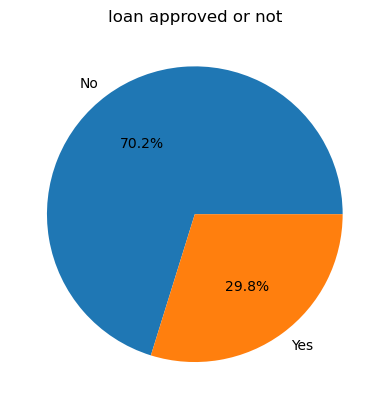

In [6]:
count_calsses=df["Loan_Approved"].value_counts()
plt.pie(count_calsses,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("loan approved or not")

<Axes: xlabel='Gender', ylabel='count'>

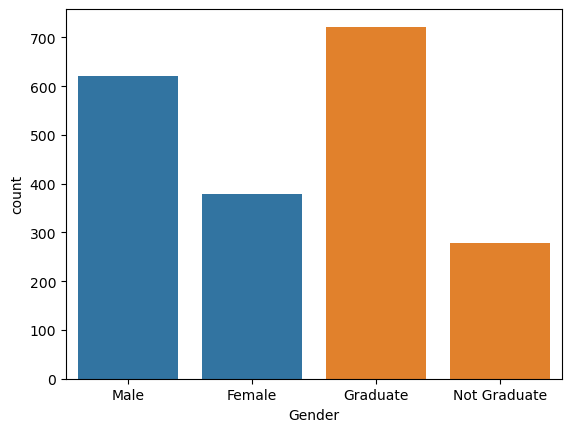

In [7]:
#analysis category
gender_cut=df["Gender"].value_counts()
sns.barplot(gender_cut)

edu_cut=df["Education_Level"].value_counts()
sns.barplot(edu_cut)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

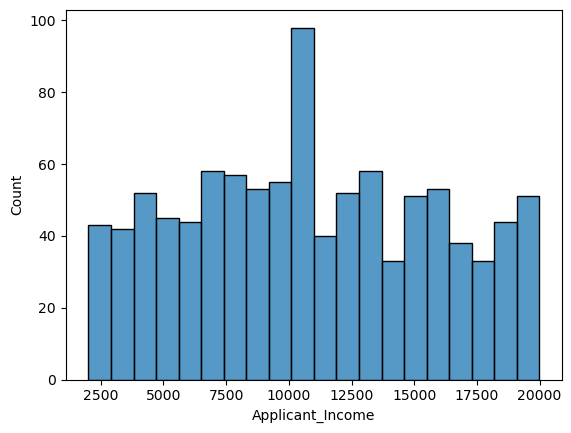

In [8]:
#ana income
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

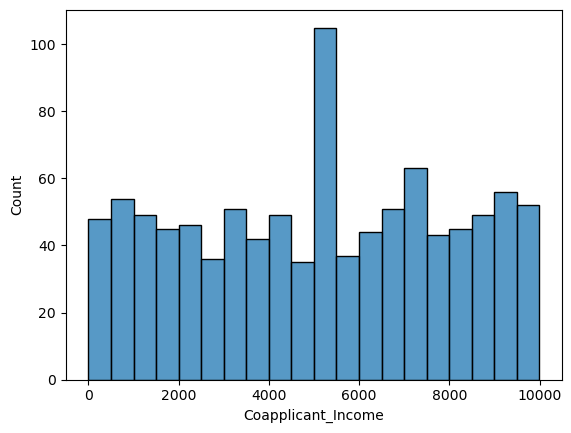

In [9]:
#ana co-income
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

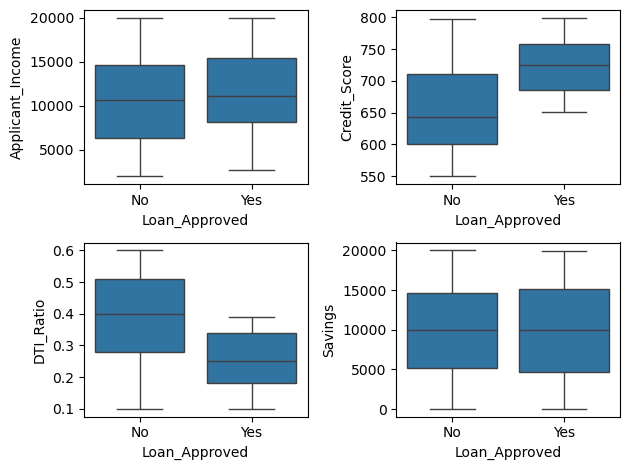

In [10]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

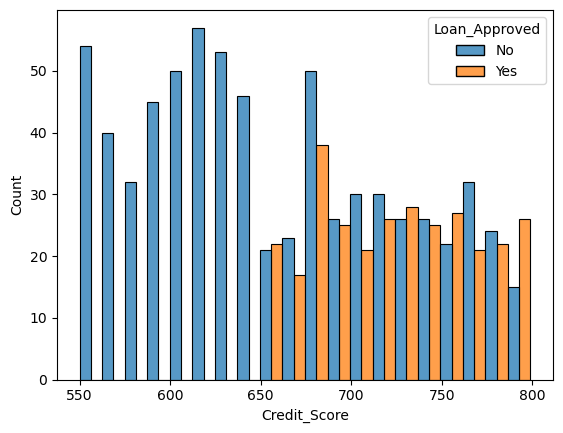

In [11]:
#relation of credit_score with loan approved
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [12]:
df.drop("Applicant_ID" ,axis=1)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

#encoding

In [13]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le=LabelEncoder()

df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

cols=["Employment_Status","Marital_Status","Employer_Category",
      "Loan_Purpose","Gender","Property_Area"]

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [14]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

#coorelation heatmap

<Axes: >

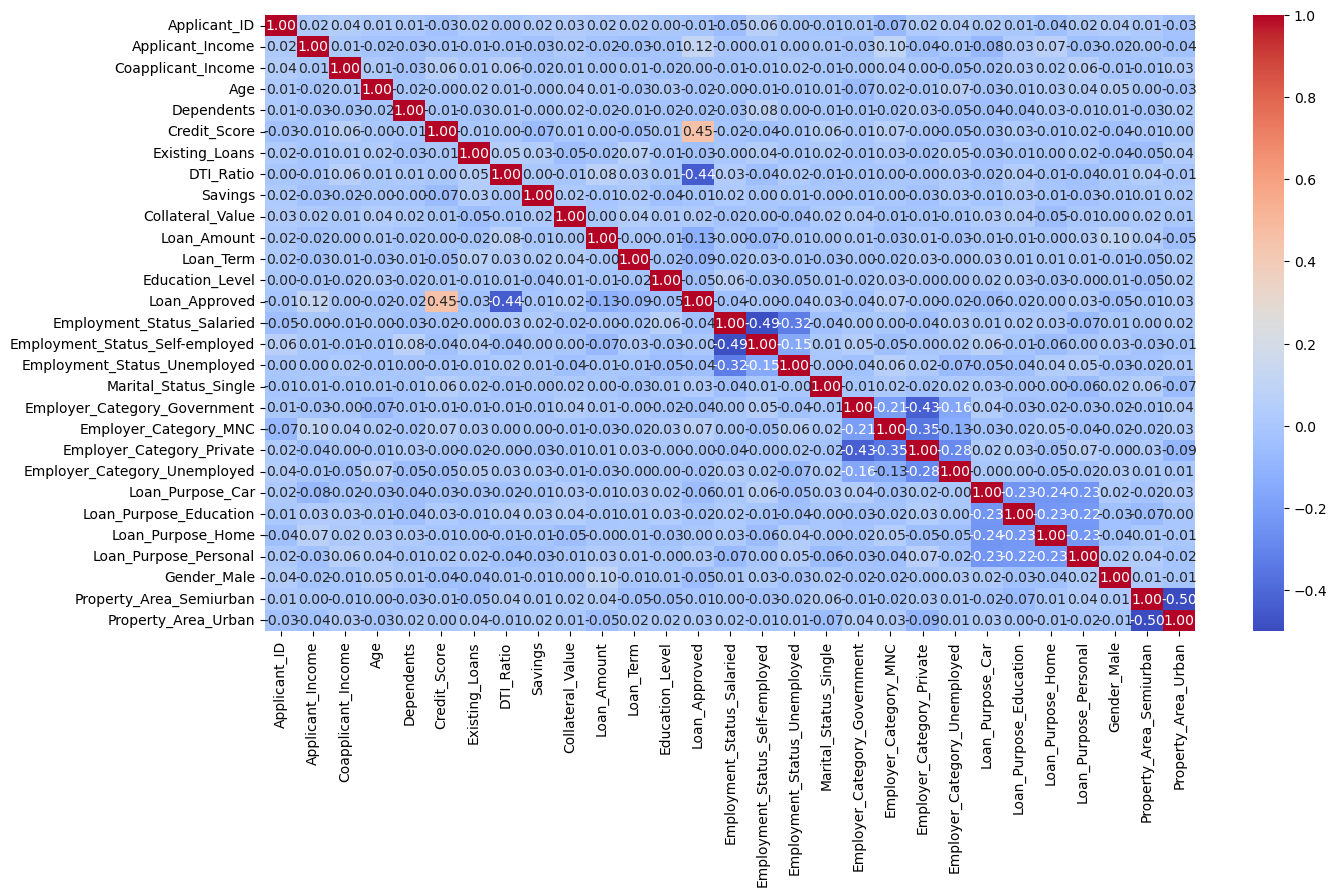

In [15]:
num_cols=df.select_dtypes("number")
corr_matrix=num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

#train test split

In [16]:
X=df.drop("Loan_Approved",axis=1)
Y=df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)


In [17]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#train  and evalute

In [18]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)


#evaluation
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix
print(f"Logistic Regression")
print(f"precision:{precision_score(y_test,y_pred)}")
print(f"REcall:{recall_score(y_test,y_pred)}")
print(f"f1:{f1_score(y_test,y_pred)}")
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")
print(f"CM:{confusion_matrix(y_test,y_pred)}")




Logistic Regression
precision:0.7868852459016393
REcall:0.7868852459016393
f1:0.7868852459016393
Accuracy:0.87
CM:[[126  13]
 [ 13  48]]


In [19]:
#KNN
from sklearn.neighbors  import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=11)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)


#evaluation
print(f"KNN classifier")
print(f"precision:{precision_score(y_test,y_pred)}")
print(f"REcall:{recall_score(y_test,y_pred)}")
print(f"f1:{f1_score(y_test,y_pred)}")
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")
print(f"CM:{confusion_matrix(y_test,y_pred)}")



KNN classifier
precision:0.6756756756756757
REcall:0.4098360655737705
f1:0.5102040816326531
Accuracy:0.76
CM:[[127  12]
 [ 36  25]]


In [20]:
#Naive bayes
from sklearn.naive_bayes  import GaussianNB
NB_model=GaussianNB()
NB_model.fit(X_train_scaled,y_train)

y_pred=NB_model.predict(X_test_scaled)


#evaluation
print(f"Naive bay")
print(f"precision:{precision_score(y_test,y_pred)}")
print(f"REcall:{recall_score(y_test,y_pred)}")
print(f"f1:{f1_score(y_test,y_pred)}")
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")
print(f"CM:{confusion_matrix(y_test,y_pred)}")


Naive bay
precision:0.8035714285714286
REcall:0.7377049180327869
f1:0.7692307692307693
Accuracy:0.865
CM:[[128  11]
 [ 16  45]]


#feature engineering

In [21]:
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

#df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"])
X=df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score"])
y=df["Loan_Approved"]


#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

#feature scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



In [22]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)


#evaluation
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix
print(f"Logistic Regression")
print(f"precision:{precision_score(y_test,y_pred)}")
print(f"REcall:{recall_score(y_test,y_pred)}")
print(f"f1:{f1_score(y_test,y_pred)}")
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")
print(f"CM:{confusion_matrix(y_test,y_pred)}")


Logistic Regression
precision:0.7903225806451613
REcall:0.8032786885245902
f1:0.7967479674796748
Accuracy:0.875
CM:[[126  13]
 [ 12  49]]


In [23]:
#KNN
from sklearn.neighbors  import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=11)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)


#evaluation
print(f"KNN classifier")
print(f"precision:{precision_score(y_test,y_pred)}")
print(f"REcall:{recall_score(y_test,y_pred)}")
print(f"f1:{f1_score(y_test,y_pred)}")
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")
print(f"CM:{confusion_matrix(y_test,y_pred)}")

KNN classifier
precision:0.7027027027027027
REcall:0.4262295081967213
f1:0.5306122448979592
Accuracy:0.77
CM:[[128  11]
 [ 35  26]]


In [24]:
#Naive bayes
from sklearn.naive_bayes  import GaussianNB
NB_model=GaussianNB()
NB_model.fit(X_train_scaled,y_train)

y_pred=NB_model.predict(X_test_scaled)


#evaluation
print(f"Naive bay")
print(f"precision:{precision_score(y_test,y_pred)}")
print(f"REcall:{recall_score(y_test,y_pred)}")
print(f"f1:{f1_score(y_test,y_pred)}")
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")
print(f"CM:{confusion_matrix(y_test,y_pred)}")


Naive bay
precision:0.7966101694915254
REcall:0.7704918032786885
f1:0.7833333333333333
Accuracy:0.87
CM:[[127  12]
 [ 14  47]]
